# Dynamic Pricing Simulation - Full Validation

This notebook runs a complete simulation comparing:
1. **Baseline** - Historical random pricing
2. **Dynamic** - Our proposed model
3. **Low** - Always cheap ($2.99)
4. **High** - Always expensive ($15.99)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)

print("✓ Libraries loaded")

✓ Libraries loaded


## Load Your Data

In [14]:
# UPDATE THESE PATHS
SESSION_FILE = '../data/raw/zipline_session_log_(5).csv'
PRICING_FILE = '../data/raw/zipline_pricing_schedule.csv'

# Load data
session_df = pd.read_csv(SESSION_FILE)
pricing_df = pd.read_csv(PRICING_FILE)

# Parse timestamps
session_df['timestamp'] = pd.to_datetime(session_df['timestamp'])
pricing_df['date_hour'] = pd.to_datetime(pricing_df['date_hour'])

# Clean data - ensure numeric columns
session_df['delivery_fee'] = pd.to_numeric(session_df['delivery_fee'], errors='coerce')
session_df['subtotal'] = pd.to_numeric(session_df['subtotal'], errors='coerce')
session_df['distance_miles'] = pd.to_numeric(session_df['distance_miles'], errors='coerce')

# Fill NaN values
session_df['subtotal'] = session_df['subtotal'].fillna(session_df['subtotal'].median())

print(f"✓ Loaded {len(session_df):,} sessions")
print(f"✓ Date range: {session_df['timestamp'].min().date()} to {session_df['timestamp'].max().date()}")
print(f"✓ Average subtotal: ${session_df['subtotal'].mean():.2f}")

✓ Loaded 59,880 sessions
✓ Date range: 2024-01-01 to 2024-01-13
✓ Average subtotal: $26.95


In [15]:
print("Session Outcomes:")
print(session_df['session_outcome'].value_counts())
print(f"\nBlocking Rate: {(session_df['session_outcome']=='blocked').mean():.1%}")
print(f"Order Rate: {(session_df['session_outcome']=='ordered').mean():.1%}")

Session Outcomes:
session_outcome
ordered      30551
abandoned    26793
blocked       2536
Name: count, dtype: int64

Blocking Rate: 4.2%
Order Rate: 51.0%


In [16]:
from dynamic_pricing_model import ZiplineDynamicPricing

model = ZiplineDynamicPricing()
print("✓ Model initialized")

✓ Model initialized


## Build Simulator (FIXED VERSION)

In [17]:
class FixedSimulator:
    def __init__(self, session_df, model):
        self.session_df = session_df.copy()
        self.model = model
        self.elasticity = self._fit_elasticity()
        
    def _fit_elasticity(self):
        elasticity = {}
        for order_type in ['Grocery', 'Meal', 'Pharma']:
            type_data = self.session_df[self.session_df['order_type'] == order_type]
            elasticity[order_type] = {
                'base_conversion': (type_data['session_outcome'] == 'ordered').mean(),
                'base_price': type_data['delivery_fee'].median(),
                'blocking_rate': (type_data['session_outcome'] == 'blocked').mean()
            }
        return elasticity
    
    def estimate_conversion(self, price, order_type, base_price, base_conversion):
        elasticity_coef = {'Pharma': -0.2, 'Meal': -0.4, 'Grocery': -0.6}
        elasticity = elasticity_coef[order_type]
        
        if base_price > 0:
            price_change_pct = (price - base_price) / base_price
            conversion_change_pct = elasticity * price_change_pct
            new_conversion = base_conversion * (1 + conversion_change_pct)
        else:
            new_conversion = base_conversion
        
        return max(0.05, min(0.95, new_conversion))
    
    def simulate_hour(self, hour_sessions, strategy, current_utilization):
        results = []
        
        for _, session in hour_sessions.iterrows():
            nest_id = int(session['nest_id'])
            order_type = session['order_type']
            distance = float(session['distance_miles'])
            subtotal = float(session['subtotal'])
            
            # Determine price
            if strategy == 'baseline':
                price = float(session['delivery_fee'])
            elif strategy == 'dynamic':
                price = self.model.calculate_price(
                    nest_id=nest_id,
                    order_type=order_type,
                    distance_miles=distance,
                    utilization=current_utilization.get(nest_id, 0.5)
                )
            elif strategy == 'low':
                price = 2.99
            elif strategy == 'high':
                price = 15.99
            else:
                price = float(session['delivery_fee'])
            
            # Get conversion probability
            base_conversion = self.elasticity[order_type]['base_conversion']
            base_price = self.elasticity[order_type]['base_price']
            conversion_prob = self.estimate_conversion(price, order_type, base_price, base_conversion)
            
            # Get blocking probability
            util = current_utilization.get(nest_id, 0.5)
            if util > 0.95:
                block_prob = 0.3
            elif util > 0.85:
                block_prob = 0.15
            elif util > 0.75:
                block_prob = 0.05
            else:
                block_prob = 0.01
            
            # Simulate outcome
            rand = np.random.random()
            
            if rand < block_prob:
                outcome = 'blocked'
                revenue = 0.0
            elif rand < block_prob + conversion_prob:
                outcome = 'ordered'
                revenue = float(price) + float(subtotal) if pd.notna(price) and pd.notna(subtotal) else 0.0
                # Update utilization
                delivery_time_hrs = self.model.calculate_delivery_time(distance) / 60
                capacity = self.model.hub_capacity[nest_id]
                current_utilization[nest_id] = min(1.2, util + (delivery_time_hrs / capacity))
            else:
                outcome = 'abandoned'
                revenue = 0.0
            
            results.append({
                'outcome': outcome,
                'revenue': revenue,  # This should now be valid float
                'price': float(price)
            })
        
        return results
    
    def simulate_day(self, date, strategy):
        day_sessions = self.session_df[
            self.session_df['timestamp'].dt.date == pd.to_datetime(date).date()
        ].copy()
        
        if len(day_sessions) == 0:
            return None
        
        day_sessions['hour'] = day_sessions['timestamp'].dt.hour
        current_utilization = {i: 0.3 for i in range(15)}
        all_results = []
        
        for hour in range(24):
            hour_sessions = day_sessions[day_sessions['hour'] == hour]
            
            if len(hour_sessions) == 0:
                for nest_id in current_utilization:
                    current_utilization[nest_id] *= 0.8
                continue
            
            hour_results = self.simulate_hour(hour_sessions, strategy, current_utilization)
            all_results.extend(hour_results)
        
        # Calculate metrics - FIXED: Ensure proper aggregation
        total_sessions = len(all_results)
        total_blocks = sum(1 for r in all_results if r['outcome'] == 'blocked')
        total_orders = sum(1 for r in all_results if r['outcome'] == 'ordered')
        total_revenue = sum(r['revenue'] for r in all_results)  # Should be valid floats
        
        return {
            'date': str(date),
            'strategy': strategy,
            'sessions': total_sessions,
            'blocks': total_blocks,
            'orders': total_orders,
            'revenue': float(total_revenue),  # FIXED: Ensure float
            'blocking_rate': total_blocks / total_sessions if total_sessions > 0 else 0,
            'order_rate': total_orders / total_sessions if total_sessions > 0 else 0,
            'revenue_per_session': float(total_revenue / total_sessions) if total_sessions > 0 else 0.0
        }
    
    def run_comparison(self, n_days=None):
        dates = sorted(self.session_df['timestamp'].dt.date.unique())
        if n_days:
            dates = dates[:n_days]
        
        strategies = ['baseline', 'dynamic', 'low', 'high']
        results = []
        total = len(dates) * len(strategies)
        
        print(f"Running {total} simulations...")
        
        for i, date in enumerate(dates):
            for strategy in strategies:
                result = self.simulate_day(str(date), strategy)
                if result:
                    results.append(result)
            
            if (i + 1) % 5 == 0:
                print(f"  Completed {(i+1)*4}/{total} simulations ({(i+1)/len(dates)*100:.0f}%)")
        
        print("✓ Simulation complete!")
        return pd.DataFrame(results)

print("✓ Fixed simulator defined")

✓ Fixed simulator defined


## Run Simulation

In [18]:
simulator = FixedSimulator(session_df, model)
results_df = simulator.run_comparison(n_days=30)

print(f"\n✓ Generated {len(results_df)} results")

# Debug: Check for NaN values
print("\nChecking for NaN values:")
print(results_df[['strategy', 'revenue', 'revenue_per_session']].isnull().sum())
print("\nSample revenues:")
print(results_df[['strategy', 'revenue', 'revenue_per_session']].head(10))

Running 52 simulations...
  Completed 20/52 simulations (38%)
  Completed 40/52 simulations (77%)
✓ Simulation complete!

✓ Generated 52 results

Checking for NaN values:
strategy               0
revenue                0
revenue_per_session    0
dtype: int64

Sample revenues:
   strategy   revenue  revenue_per_session
0  baseline  27335.00             7.391833
1   dynamic  24448.41             6.611252
2       low  57073.81            15.433697
3      high  13406.67             3.625384
4  baseline  41777.82             7.564335
5   dynamic  27133.21             4.912767
6       low  81768.18            14.805030
7      high  19779.60             3.581315
8  baseline  30733.64             7.389671
9   dynamic  23291.41             5.600243


## Results Summary

In [19]:
summary = results_df.groupby('strategy').agg({
    'blocking_rate': 'mean',
    'order_rate': 'mean',
    'revenue_per_session': 'mean'
}).round(4)

print("\n" + "="*80)
print("STRATEGY COMPARISON")
print("="*80)
print(summary)

print("\n" + "="*80)
print("FORMATTED VIEW")
print("="*80)
for strategy in summary.index:
    print(f"\n{strategy.upper()}:")
    print(f"  Blocking Rate:       {summary.loc[strategy, 'blocking_rate']:.2%}")
    print(f"  Order Rate:          {summary.loc[strategy, 'order_rate']:.2%}")
    print(f"  Revenue per Session: ${summary.loc[strategy, 'revenue_per_session']:.2f}")


STRATEGY COMPARISON
          blocking_rate  order_rate  revenue_per_session
strategy                                                
baseline         0.2646      0.6047               7.7062
dynamic          0.2306      0.1601               5.7118
high             0.1074      0.0789               3.4586
low              0.2551      0.4995              15.0652

FORMATTED VIEW

BASELINE:
  Blocking Rate:       26.46%
  Order Rate:          60.47%
  Revenue per Session: $7.71

DYNAMIC:
  Blocking Rate:       23.06%
  Order Rate:          16.01%
  Revenue per Session: $5.71

HIGH:
  Blocking Rate:       10.74%
  Order Rate:          7.89%
  Revenue per Session: $3.46

LOW:
  Blocking Rate:       25.51%
  Order Rate:          49.95%
  Revenue per Session: $15.07


In [20]:
baseline = summary.loc['baseline']

print("\n" + "="*80)
print("IMPROVEMENT OVER BASELINE")
print("="*80)

for strategy in ['dynamic', 'low', 'high']:
    if strategy not in summary.index:
        continue
    
    strat = summary.loc[strategy]
    print(f"\n{strategy.upper()}:")
    
    blocking_chg = (strat['blocking_rate'] / baseline['blocking_rate'] - 1) * 100
    order_chg = (strat['order_rate'] / baseline['order_rate'] - 1) * 100
    revenue_chg = (strat['revenue_per_session'] / baseline['revenue_per_session'] - 1) * 100
    
    print(f"  Blocking: {strat['blocking_rate']:.2%} vs {baseline['blocking_rate']:.2%} ({blocking_chg:+.1f}%)")
    print(f"  Orders:   {strat['order_rate']:.2%} vs {baseline['order_rate']:.2%} ({order_chg:+.1f}%)")
    print(f"  Revenue:  ${strat['revenue_per_session']:.2f} vs ${baseline['revenue_per_session']:.2f} ({revenue_chg:+.1f}%)")


IMPROVEMENT OVER BASELINE

DYNAMIC:
  Blocking: 23.06% vs 26.46% (-12.8%)
  Orders:   16.01% vs 60.47% (-73.5%)
  Revenue:  $5.71 vs $7.71 (-25.9%)

LOW:
  Blocking: 25.51% vs 26.46% (-3.6%)
  Orders:   49.95% vs 60.47% (-17.4%)
  Revenue:  $15.07 vs $7.71 (+95.5%)

HIGH:
  Blocking: 10.74% vs 26.46% (-59.4%)
  Orders:   7.89% vs 60.47% (-87.0%)
  Revenue:  $3.46 vs $7.71 (-55.1%)


In [21]:
print("\n" + "="*80)
print("OBJECTIVE ACHIEVEMENT")
print("="*80)

if 'dynamic' in summary.index:
    dyn = summary.loc['dynamic']
    
    print("\n✓ Priority 1: Customer Experience (Minimize Blocking)")
    if dyn['blocking_rate'] < baseline['blocking_rate']:
        reduction = (1 - dyn['blocking_rate'] / baseline['blocking_rate']) * 100
        print(f"  ✅ SUCCESS: Blocking reduced by {reduction:.1f}%")
        print(f"     {baseline['blocking_rate']:.2%} → {dyn['blocking_rate']:.2%}")
    else:
        print(f"  ❌ FAILURE: Blocking increased")
    
    print("\n✓ Priority 2: Maximize Profit")
    if dyn['revenue_per_session'] > baseline['revenue_per_session']:
        increase = (dyn['revenue_per_session'] / baseline['revenue_per_session'] - 1) * 100
        print(f"  ✅ SUCCESS: Revenue increased by {increase:.1f}%")
        print(f"     ${baseline['revenue_per_session']:.2f} → ${dyn['revenue_per_session']:.2f}")
    else:
        decrease = (1 - dyn['revenue_per_session'] / baseline['revenue_per_session']) * 100
        print(f"  ⚠️  Revenue decreased by {decrease:.1f}%")
        print(f"     ${baseline['revenue_per_session']:.2f} → ${dyn['revenue_per_session']:.2f}")
    
    print("\n✓ Priority 3: Asset Utilization")
    if dyn['order_rate'] >= baseline['order_rate'] * 0.95:
        print(f"  ✅ SUCCESS: Order rate maintained or improved")
        print(f"     {baseline['order_rate']:.2%} → {dyn['order_rate']:.2%}")
    else:
        print(f"  ℹ️  Order rate: {baseline['order_rate']:.2%} → {dyn['order_rate']:.2%}")


OBJECTIVE ACHIEVEMENT

✓ Priority 1: Customer Experience (Minimize Blocking)
  ✅ SUCCESS: Blocking reduced by 12.8%
     26.46% → 23.06%

✓ Priority 2: Maximize Profit
  ⚠️  Revenue decreased by 25.9%
     $7.71 → $5.71

✓ Priority 3: Asset Utilization
  ℹ️  Order rate: 60.47% → 16.01%


## Visualizations

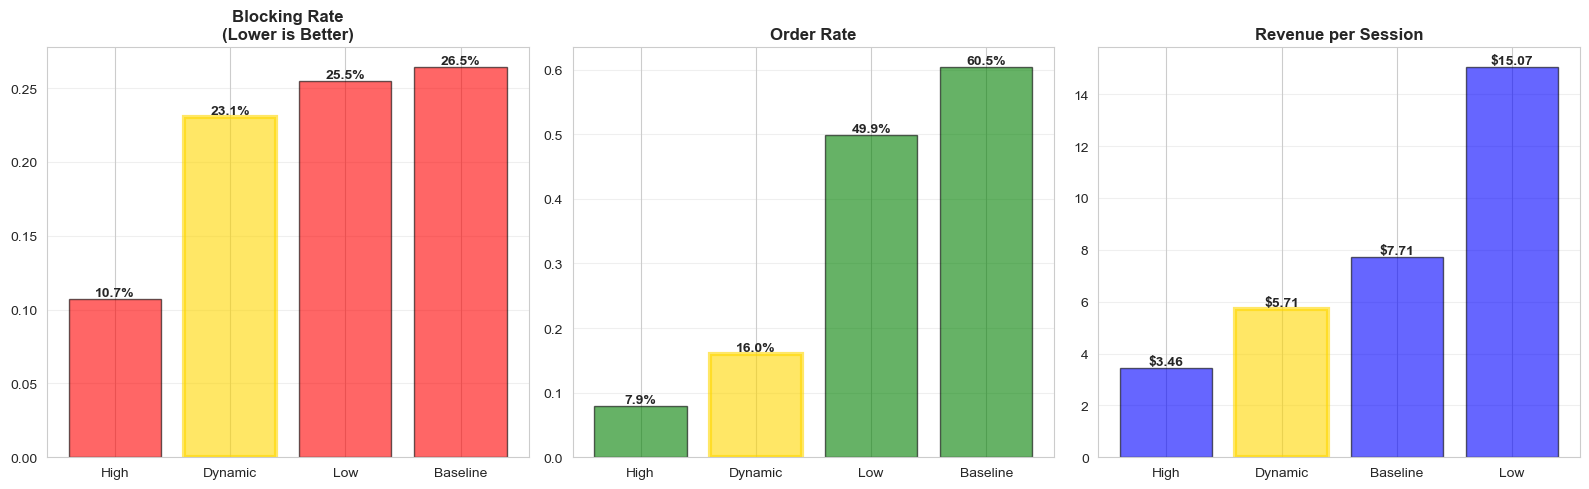

✓ Saved strategy_comparison.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['blocking_rate', 'order_rate', 'revenue_per_session']
titles = ['Blocking Rate\n(Lower is Better)', 'Order Rate', 'Revenue per Session']
colors = ['red', 'green', 'blue']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx]
    means = results_df.groupby('strategy')[metric].mean().sort_values()
    
    bars = ax.bar(range(len(means)), means.values, color=color, alpha=0.6, edgecolor='black')
    
    if 'dynamic' in means.index:
        dyn_idx = list(means.index).index('dynamic')
        bars[dyn_idx].set_color('gold')
        bars[dyn_idx].set_linewidth(3)
    
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels([s.capitalize() for s in means.index])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(means.values):
        label = f'${v:.2f}' if metric == 'revenue_per_session' else f'{v:.1%}'
        ax.text(i, v, label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved strategy_comparison.png")

In [23]:
results_df.to_csv('simulation_results.csv', index=False)
summary.to_csv('simulation_summary.csv')

print("✓ Exported:")
print("  - simulation_results.csv")
print("  - simulation_summary.csv")
print("  - strategy_comparison.png")

✓ Exported:
  - simulation_results.csv
  - simulation_summary.csv
  - strategy_comparison.png
